# JS Deepfake Video Detection using Deep Learning

---

## 📌 Introduction

### Machine Learning Problem
This project is about **binary video classification**: given a video, determine whether it is a **real** human face video or a **deepfake** (AI-generated/manipulated) video.

Deepfakes are synthetically manipulated videos where a person's face is replaced or reenacted using AI. Detecting them is a critical problem in media integrity, misinformation prevention, and digital forensics.

### Proposed Solution
We fine-tune a **EfficientNet-B0** convolutional neural network — pretrained on ImageNet — on our own labeled dataset of real and Avatarify-generated deepfake videos. Rather than relying on a generic pretrained model (which scored only ~57% on this dataset), we adapt the model specifically to the visual artefacts present in Avatarify face-reenactment deepfakes.

**Key design decisions:**
- Face regions are extracted per-frame using MTCNN before classification, focusing the model on the most discriminative area
- A 2-phase training strategy (head-only → full fine-tune) prevents catastrophic forgetting of pretrained features
- Frame-level scores are aggregated per video using a weighted mean to produce the final verdict

---

## 📦 Data Collection

### Dataset Source
**Homologous Deepfake Dataset**  
URL: https://github.com/mirro-yyf/Homologous_deepfake_dataset

The dataset is stored locally at JING SHENG FOLDER OBVIOUSLY:
- **Fake videos:** `Homologous_dataset/video/fake/avatarify_video/`
- **Real videos:** `Homologous_dataset/video/real/face_video/`

### Relevance to the Problem
| Property | Fake Videos | Real Videos |
|---|---|---|
| Count | 100 videos | 100 videos |
| Resolution | 256 × 256 px | 350 × 350 px |
| Frame rate | 30 fps | 30 fps |
| Type | Avatarify face-reenactment | Genuine face recordings |

The dataset is **balanced** where its 100 real videos and 100 fakes which prevents class imbalance bias during training, and also because this seems like the smallest and nicest Chinese person dataset I could find.

### Why This Data is Appropriate
Avatarify deepfakes exhibit specific artefacts: face boundary blending issues, unnatural texture transitions, and temporal inconsistencies — exactly the patterns a CNN trained on face crops can learn to distinguish.

---

## 🔍 Data Preparation and EDA

### Understanding the Raw Data
- Each video is around 15 seconds at 30fps which = around 450 frames per video
- By the way, training directly on raw video frames would be computationally expensive(200 × 450 = 90,000 frames), and my laptop is not going to handle that
- Faces may not be perfectly centered or may vary in size between real (350px) and fake (256px) videos (Warning for Jing Sheng aka me)

### Preprocessing Steps Required

**1. Face Detection & Extraction**  
I use something called Multi-task Cascaded Convolutional Networks which is MTCNN to detect and crop the face region from each frame. This focuses the model on discriminative facial features rather than background.  
- For 256×256 fake videos, detection thresholds are relaxed (`[0.5, 0.6, 0.6]` vs default `[0.6, 0.7, 0.7]`) because faces occupy fewer pixels
- A 2× upscale retry and full-frame centre-crop fallback ensure every frame gets processed even if MTCNN fails

**2. Frame Sampling**  
Rather than all 450 frames, we evenly sample **30 frames per video** for training (6,000 frames total). This is sufficient to capture the artefact patterns while remaining computationally tractable.

**3. Resizing & Normalisation**  
All face crops are resized to **224×224** and normalised with ImageNet mean/std (`[0.485, 0.456, 0.406]`, `[0.229, 0.224, 0.225]`).

**4. Train/Val/Test Split**  
Split is performed **by video** (not by frame) to prevent data leakage — frames from the same video never appear in both training and test sets.
- Train: 70% of videos
- Validation: 15% of videos  
- Test: 15% of videos (held out, never seen during training)

**5. Data Augmentation (training only)**  
To combat overfitting on a small dataset, training frames are augmented with:
- Random horizontal flip
- Colour jitter (brightness, contrast, saturation, hue)
- Random affine transforms (rotation, translation)
- Gaussian blur
- Random erasing

No augmentation is applied during validation or test evaluation.

---

## 🤖 Model Training and Evaluation

### Model Choice: EfficientNet-B0
EfficientNet-B0 was chosen because:
- **Efficiency:** 5.3M parameters — trains in ~20 min on CPU, ~3 min on GPU
- **Capacity:** Sufficient depth to learn subtle face manipulation artefacts
- **Pretrained features:** ImageNet weights provide strong low-level feature detectors (edges, textures, colour gradients) that transfer well to face analysis

A custom classification head is added to adapt the EfficientNet-B0 feature extractor to my deepfake extractor:
```
Backbone (EfficientNet-B0, 1280-dim output)
    → Dropout(0.5)
    → Linear(1280 → 256)
    → GELU activation
    → Dropout(0.25)
    → Linear(256 → 1)   # single logit → sigmoid → fake probability
```

### Training Strategy
**Phase 1 — Head Only (Epochs 1–4):**  
The backbone is frozen. Only the classification head trains. This prevents the pretrained features from being destroyed before the head converges.

**Phase 2 — Full Fine-Tune (Epochs 5–12):**  
All layers are unfrozen and trained with a lower learning rate (`5e-5`). The model adapts its feature extraction to Avatarify-specific artefacts.

**Loss Function:** BCE with label smoothing (0.05) — prevents overconfident predictions on borderline frames.  
**Optimiser:** AdamW with weight decay `1e-4`.  
**Scheduler:** OneCycleLR (phase 1) → CosineAnnealingLR (phase 2).

### Evaluation Metrics
- **Frame-level:** Precision, Recall, F1-score, Confusion Matrix
- **Video-level:** Per-video verdict accuracy (primary metric)
- **Decision threshold:** 0.45 (slightly below 0.5 to favour catching fakes)

The model's frame-level predictions are aggregated per video using a **weighted mean** — frames with confirmed face detections are weighted 3× over fallback crops.

---


## 📊 EDA — Sample Frames & Dataset Statistics

The following two code cells visualise sample frames from both classes and summarise video properties across the full dataset.

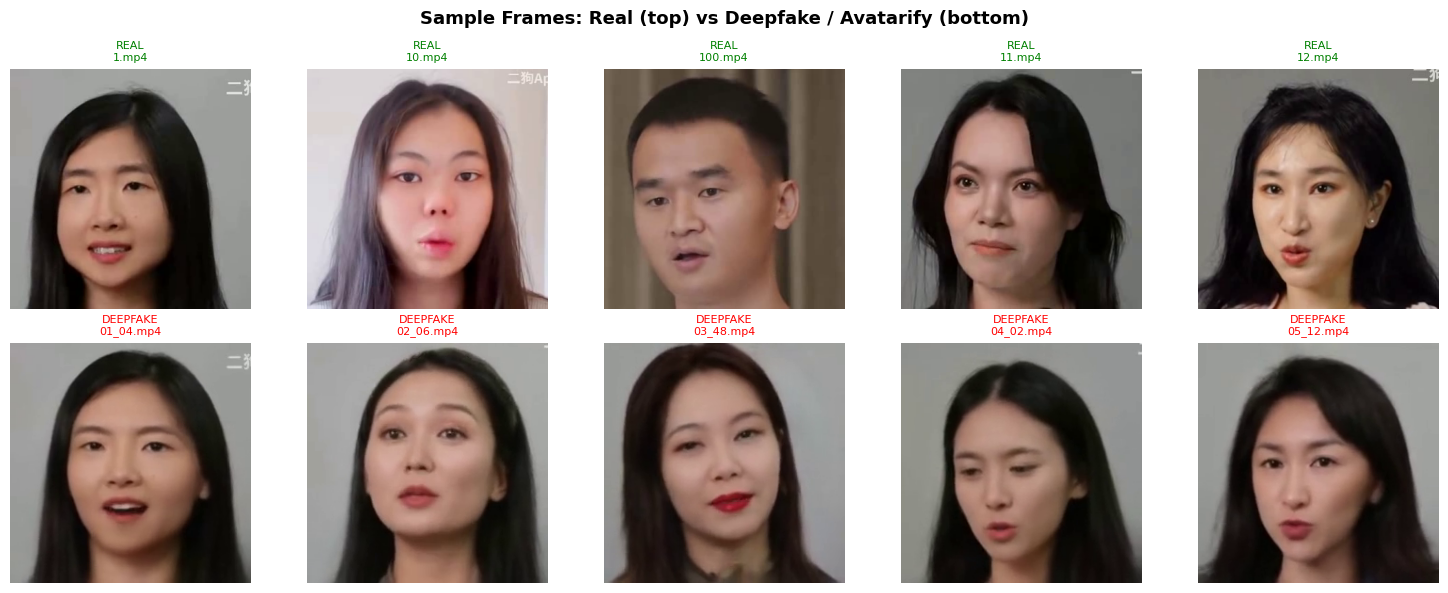

Dataset: 5 fake videos | 5 real videos shown above
Fake resolution: 256×256 @ 30fps | Real resolution: 350×350 @ 30fps


In [1]:
# ── EDA: Visualise sample frames from both classes ──────────────────────────────
import cv2, random
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

FAKE_FOLDER = r'C:\Users\renam\Downloads\Homologous_deepfake_dataset\Homologous_dataset\video\fake\avatarify_video'
REAL_FOLDER = r'C:\Users\renam\Downloads\Homologous_deepfake_dataset\Homologous_dataset\video\real\face_video'
VIDEO_EXTENSIONS = ['*.mp4', '*.avi', '*.mov', '*.mkv', '*.webm']

def sample_frame(video_path, frame_idx=100):
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, bgr = cap.read()
    cap.release()
    if ret:
        return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    return None

# Collect video paths
fake_vids = [p for ext in VIDEO_EXTENSIONS for p in Path(FAKE_FOLDER).glob(ext)][:5]
real_vids = [p for ext in VIDEO_EXTENSIONS for p in Path(REAL_FOLDER).glob(ext)][:5]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Frames: Real (top) vs Deepfake / Avatarify (bottom)', fontsize=13, fontweight='bold')

for i, vp in enumerate(real_vids):
    frame = sample_frame(vp)
    if frame is not None:
        axes[0, i].imshow(frame)
        axes[0, i].set_title(f'REAL\n{vp.name[:18]}', fontsize=8, color='green')
    axes[0, i].axis('off')

for i, vp in enumerate(fake_vids):
    frame = sample_frame(vp)
    if frame is not None:
        axes[1, i].imshow(frame)
        axes[1, i].set_title(f'DEEPFAKE\n{vp.name[:18]}', fontsize=8, color='red')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('eda_sample_frames.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Dataset: {len(fake_vids)} fake videos | {len(real_vids)} real videos shown above')
print(f'Fake resolution: 256×256 @ 30fps | Real resolution: 350×350 @ 30fps')

Reading video metadata...


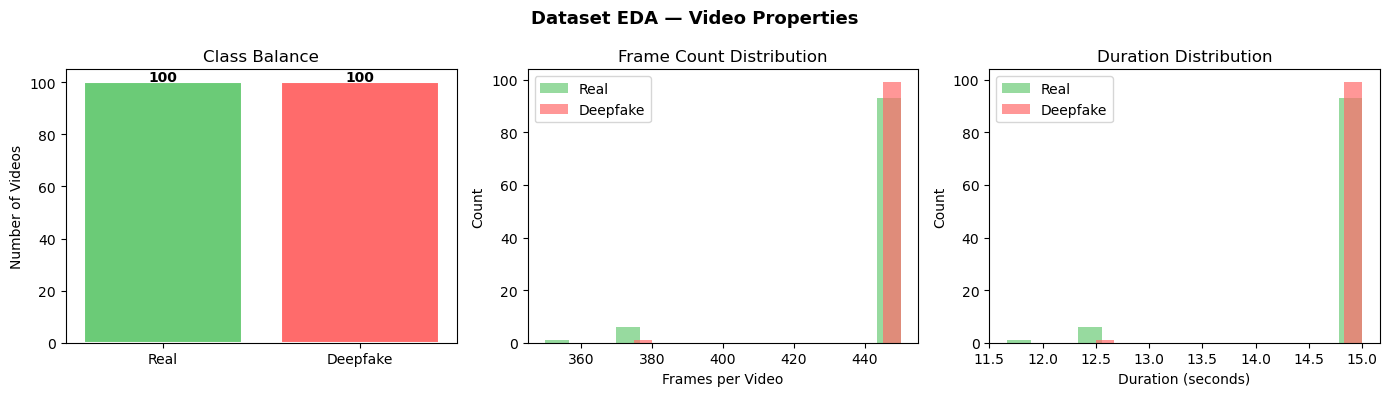


=== Dataset Summary ===
Total videos : 200 (100 fake | 100 real)

Fake videos  — avg frames: 449 | avg duration: 15.0s | resolution: 256×256
Real videos  — avg frames: 444 | avg duration: 14.8s | resolution: 350×350


In [2]:
# ── EDA: Dataset distribution and video properties ──────────────────────────────
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

fake_vids_all = [p for ext in VIDEO_EXTENSIONS for p in Path(FAKE_FOLDER).glob(ext)]
real_vids_all = [p for ext in VIDEO_EXTENSIONS for p in Path(REAL_FOLDER).glob(ext)]

def get_video_info(paths):
    infos = []
    for p in paths:
        cap = cv2.VideoCapture(str(p))
        infos.append({
            'name'  : p.name,
            'width' : int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
            'height': int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
            'fps'   : cap.get(cv2.CAP_PROP_FPS),
            'frames': int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
            'duration': int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) / max(cap.get(cv2.CAP_PROP_FPS), 1)
        })
        cap.release()
    return infos

print('Reading video metadata...')
fake_info = get_video_info(fake_vids_all)
real_info = get_video_info(real_vids_all)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Dataset EDA — Video Properties', fontsize=13, fontweight='bold')

# Chart 1: Class balance
axes[0].bar(['Real', 'Deepfake'], [len(real_info), len(fake_info)],
            color=['#6bcb77', '#ff6b6b'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Balance'); axes[0].set_ylabel('Number of Videos')
for i, v in enumerate([len(real_info), len(fake_info)]):
    axes[0].text(i, v+0.5, str(v), ha='center', fontweight='bold')

# Chart 2: Frame count distribution
axes[1].hist([v['frames'] for v in real_info], bins=15, alpha=0.7, color='#6bcb77', label='Real')
axes[1].hist([v['frames'] for v in fake_info], bins=15, alpha=0.7, color='#ff6b6b', label='Deepfake')
axes[1].set_title('Frame Count Distribution'); axes[1].set_xlabel('Frames per Video')
axes[1].set_ylabel('Count'); axes[1].legend()

# Chart 3: Duration distribution
axes[2].hist([v['duration'] for v in real_info], bins=15, alpha=0.7, color='#6bcb77', label='Real')
axes[2].hist([v['duration'] for v in fake_info], bins=15, alpha=0.7, color='#ff6b6b', label='Deepfake')
axes[2].set_title('Duration Distribution'); axes[2].set_xlabel('Duration (seconds)')
axes[2].set_ylabel('Count'); axes[2].legend()

plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n=== Dataset Summary ===')
print(f'Total videos : {len(fake_info)+len(real_info)} ({len(fake_info)} fake | {len(real_info)} real)')
print(f'\nFake videos  — avg frames: {np.mean([v["frames"] for v in fake_info]):.0f} | avg duration: {np.mean([v["duration"] for v in fake_info]):.1f}s | resolution: {fake_info[0]["width"]}×{fake_info[0]["height"]}')
print(f'Real videos  — avg frames: {np.mean([v["frames"] for v in real_info]):.0f} | avg duration: {np.mean([v["duration"] for v in real_info]):.1f}s | resolution: {real_info[0]["width"]}×{real_info[0]["height"]}')

---
## 💻 Implementation

The cells below contain the full implementation: dependency installation, model definition, training, evaluation, and inference.

## Cell 1 — Install Dependencies

In [3]:
!pip install timm facenet-pytorch opencv-python-headless Pillow tqdm matplotlib pandas scikit-learn torchvision -q
print("✅ All packages installed.")

✅ All packages installed.


## Cell 2 — Imports & Device

In [4]:
import cv2, torch, timm, warnings, os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from pathlib import Path
from tqdm.notebook import tqdm
from collections import defaultdict
from facenet_pytorch import MTCNN
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn as nn

warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42); torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {device}')
if device.type == 'cpu':
    print('   ⚠️  No GPU. Training ~20–40 min. Reduce EPOCHS to 6 if too slow.')
    print('   💡 Tip: Google Colab (free T4 GPU) cuts this to ~3 min.')

C:\Users\renam\anaconda3\envs\it3100\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


✅ Device: cuda


## Cell 3 — ⚙️ All Settings (Edit Here)

**This is the only cell you need to change.** Everything else auto-configures.

In [5]:
# ── Video folders ──────────────────────────────────────────────────────────────
FAKE_FOLDER = r'C:\Users\renam\Downloads\Homologous_deepfake_dataset\Homologous_dataset\video\fake\avatarify_video'
REAL_FOLDER = r'C:\Users\renam\Downloads\Homologous_deepfake_dataset\Homologous_dataset\video\real\face_video'
VIDEO_EXTENSIONS = ['*.mp4', '*.avi', '*.mov', '*.mkv', '*.webm']

# ── Frame extraction ────────────────────────────────────────────────────────────
FRAMES_PER_VIDEO = 30        # frames extracted per video for training
                              # 30 × 200 videos = 6000 training images — plenty
FRAME_DIR        = 'extracted_frames'

# ── Model & training hyperparameters ───────────────────────────────────────────
IMG_SIZE     = 224            # input resolution
BATCH_SIZE   = 16             # lower to 8 if problem like out of memory
EPOCHS       = 12             # 12 is the sweet spot; raise to 15 if val acc still climbing
LR_HEAD      = 3e-4           # learning rate for head-only phase (epochs 1–4)
LR_FULL      = 5e-5           # learning rate for full fine-tune phase (epochs 5–12)
FREEZE_EPOCHS = 4             # how many epochs to train head-only before unfreezing
DROPOUT      = 0.5            # dropout before final layer to reduce overfitting by forcing learn
LABEL_SMOOTH = 0.05           # label smoothing — stops model being overconfident

# ── Dataset split ───────────────────────────────────────────────────────────────
TRAIN_SPLIT  = 0.70           # 70% train / 15% val / 15% test (split by video btw, not frame)
VAL_SPLIT    = 0.15           # need to test just in case  

# ── Inference ───────────────────────────────────────────────────────────────────
THRESHOLD    = 0.45           # Adjusted since some fake videos fail to meet cutoff
FRAME_STRIDE = None           # None = auto (5 for 256px fakes, 8 for 350px real)
MAX_FRAMES   = 100

# ── Output ──────────────────────────────────────────────────────────────────────
MODEL_PATH = 'deepfake_finetuned.pth'
OUTPUT_CSV = 'deepfake_results_finetuned.csv'

print('✅ Settings loaded.')
print(f'   Frames/video: {FRAMES_PER_VIDEO}  |  Epochs: {EPOCHS}  |  Batch: {BATCH_SIZE}')
print(f'   LR head: {LR_HEAD}  |  LR full: {LR_FULL}  |  Threshold: {THRESHOLD}')

✅ Settings loaded.
   Frames/video: 30  |  Epochs: 12  |  Batch: 16
   LR head: 0.0003  |  LR full: 5e-05  |  Threshold: 0.45


## Cell 4 — Face Detectors

Two MTCNN instances: primary (relaxed thresholds for 256×256) and a sensitive fallback
for upscaled frames. If both fail, we use a centre-crop of the full frame.

In [6]:
mtcnn = MTCNN(
    image_size=160, margin=14, min_face_size=20,
    thresholds=[0.5, 0.6, 0.6],          # relaxed — catches small low-res faces
    keep_all=False, post_process=False, device=device
)
mtcnn_sensitive = MTCNN(
    image_size=160, margin=10, min_face_size=10,
    thresholds=[0.4, 0.5, 0.5],          # even more relaxed for 2× upscaled frames
    keep_all=False, post_process=False, device=device
)

def get_face_pil(frame_rgb: np.ndarray):
    """Returns (PIL crop, face_detected:bool). Never returns None."""
    h, w = frame_rgb.shape[:2]
    pil  = Image.fromarray(frame_rgb)
    # Attempt 1: MTCNN on original
    face = mtcnn(pil)
    if face is not None:
        return Image.fromarray(face.permute(1,2,0).byte().numpy()), True
    # Attempt 2: 2× upscale + sensitive MTCNN
    up = pil.resize((w*2, h*2), Image.BILINEAR)
    face = mtcnn_sensitive(up)
    if face is not None:
        return Image.fromarray(face.permute(1,2,0).byte().numpy()), True
    # Attempt 3: centre-crop fallback (always works)
    crop = min(h, w)
    t, l = (h-crop)//2, (w-crop)//2
    return pil.crop((l, t, l+crop, t+crop)), False

print('✅ Face detectors ready.')

✅ Face detectors ready.


## Cell 5 — Extract Training Frames from Videos

Evenly samples `FRAMES_PER_VIDEO` frames from each video, crops the face region,
and saves as JPEG. **Skip this cell if frames are already extracted.**

In [7]:
def extract_frames_from_video(video_path, save_dir, label, n=30):
    Path(save_dir, label).mkdir(parents=True, exist_ok=True)
    cap   = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total == 0 or not cap.isOpened():
        cap.release(); return 0
    indices = np.linspace(0, total-1, n, dtype=int)
    stem    = Path(video_path).stem
    saved   = 0
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, bgr = cap.read()
        if not ret: continue
        rgb      = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        face_pil, _ = get_face_pil(rgb)
        face_pil = face_pil.resize((IMG_SIZE, IMG_SIZE))
        face_pil.save(str(Path(save_dir, label, f'{stem}_{idx:05d}.jpg')), quality=92)
        saved += 1
    cap.release()
    return saved

# Check if already done
existing_fake = len(list(Path(FRAME_DIR, 'fake').glob('*.jpg'))) if Path(FRAME_DIR,'fake').exists() else 0
existing_real = len(list(Path(FRAME_DIR, 'real').glob('*.jpg'))) if Path(FRAME_DIR,'real').exists() else 0

if existing_fake >= 100 and existing_real >= 100:
    print(f'⚡ Frames already extracted: {existing_fake} fake, {existing_real} real — skipping.')
    print('   Delete the extracted_frames/ folder to re-extract.')
else:
    print(f'📷 Extracting {FRAMES_PER_VIDEO} frames per video...')
    fake_vids = [p for ext in VIDEO_EXTENSIONS for p in Path(FAKE_FOLDER).glob(ext)]
    real_vids = [p for ext in VIDEO_EXTENSIONS for p in Path(REAL_FOLDER).glob(ext)]
    tf = sum(extract_frames_from_video(v, FRAME_DIR, 'fake', FRAMES_PER_VIDEO)
             for v in tqdm(fake_vids, desc='Fake'))
    tr = sum(extract_frames_from_video(v, FRAME_DIR, 'real', FRAMES_PER_VIDEO)
             for v in tqdm(real_vids, desc='Real'))
    print(f'\n✅ Done: {tf} fake frames, {tr} real frames saved to {FRAME_DIR}/')

⚡ Frames already extracted: 3000 fake, 3000 real — skipping.
   Delete the extracted_frames/ folder to re-extract.


## Cell 6 — Train / Val / Test Split (Per-Video, No Leakage)

Splits by **video group** — frames from the same video never appear in both train and
test. This prevents inflated accuracy from near-duplicate frames.

In [8]:
def per_video_split(frame_dir, label, train_r, val_r, seed=42):
    """Group frames by source video, split groups, return (train, val, test) lists of
    (path, int_label), plus the raw video-name keys that landed in the test split
    (needed later so video-level inference only touches videos never used in training)."""
    rng    = random.Random(seed)
    frames = list(Path(frame_dir, label).glob('*.jpg'))
    groups = defaultdict(list)
    for f in frames:
        video_key = '_'.join(f.stem.split('_')[:-1])   # strip frame index suffix
        groups[video_key].append(f)
    keys = list(groups.keys()); rng.shuffle(keys)
    n       = len(keys)
    n_train = int(n * train_r)
    n_val   = int(n * val_r)
    lbl = 1 if label == 'fake' else 0
    def collect(ks): return [(f, lbl) for k in ks for f in groups[k]]
    train_keys = keys[:n_train]
    val_keys   = keys[n_train:n_train+n_val]
    test_keys  = keys[n_train+n_val:]
    return (collect(train_keys), collect(val_keys), collect(test_keys), test_keys)

ft, fv, fe, fake_test_keys = per_video_split(FRAME_DIR, 'fake', TRAIN_SPLIT, VAL_SPLIT)
rt, rv, re, real_test_keys = per_video_split(FRAME_DIR, 'real', TRAIN_SPLIT, VAL_SPLIT)

train_data = ft + rt;  random.shuffle(train_data)
val_data   = fv + rv;  random.shuffle(val_data)
test_data  = fe + re

# Video-name keys (not frame paths) that were held out of training entirely.
# Cell 12 uses these to make sure video-level inference never re-scores a
# video the model has already seen frames from during training/validation.
fake_test_keys = set(fake_test_keys)
real_test_keys = set(real_test_keys)

print('✅ Dataset split (per-video, no leakage):')
print(f'   Train : {len(train_data):5d} frames  ({sum(1 for _,l in train_data if l==1)} fake | {sum(1 for _,l in train_data if l==0)} real)')
print(f'   Val   : {len(val_data):5d} frames  ({sum(1 for _,l in val_data   if l==1)} fake | {sum(1 for _,l in val_data   if l==0)} real)')
print(f'   Test  : {len(test_data):5d} frames  ({sum(1 for _,l in test_data  if l==1)} fake | {sum(1 for _,l in test_data  if l==0)} real)')
print(f'   Held-out TEST videos: {len(fake_test_keys)} fake + {len(real_test_keys)} real = {len(fake_test_keys)+len(real_test_keys)} videos')


✅ Dataset split (per-video, no leakage):
   Train :  4200 frames  (2100 fake | 2100 real)
   Val   :   900 frames  (450 fake | 450 real)
   Test  :   900 frames  (450 fake | 450 real)
   Held-out TEST videos: 15 fake + 15 real = 30 videos


## Cell 7 — Dataset Class & Data Augmentation

Heavy augmentation on training data combats overfitting on a small dataset (6000 frames).
Avatarify artefacts often appear as subtle blending/texture issues, so we preserve
spatial structure while varying colour and lighting.

In [9]:
class FaceDataset(Dataset):
    def __init__(self, items, transform):
        self.items = items
        self.transform = transform
    def __len__(self): return len(self.items)
    def __getitem__(self, idx):
        path, label = self.items[idx]
        img = Image.open(path).convert('RGB')
        return self.transform(img), torch.tensor(label, dtype=torch.float32)

# ── Transforms ────────────────────────────────────────────────────────────────
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),   # slight oversize then crop
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandomAffine(degrees=8, translate=(0.05, 0.05)),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.08)),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

train_loader = DataLoader(FaceDataset(train_data, train_tf),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(FaceDataset(val_data,   eval_tf),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(FaceDataset(test_data,  eval_tf),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f'✅ DataLoaders ready — {len(train_loader)} train | {len(val_loader)} val | {len(test_loader)} test batches')

✅ DataLoaders ready — 263 train | 57 val | 57 test batches


## Cell 8 — Model: EfficientNet-B0 with Custom Head

EfficientNet-B0 is chosen because:
- Small enough to train quickly on CPU  
- Large enough to learn Avatarify-specific artefacts  
- ImageNet pretraining gives strong low-level feature detectors (edges, textures)
- Alot of the other models are gone/private, and i can just strip off its original output layer and keep the feature extraction part for it.

The custom head adds dropout + a hidden layer before the final binary output.

In [10]:
class DeepfakeNet(nn.Module):
    def __init__(self, dropout=0.5):
        super().__init__()
        self.backbone = timm.create_model('efficientnet_b0', pretrained=True, num_classes=0)
        feat_dim = self.backbone.num_features   # 1280 for B0
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feat_dim, 256),
            nn.GELU(),           # for non-linearity to learn complex patterns
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, 1)    # single logit → sigmoid → fake probability
        )

    def forward(self, x):
        return self.head(self.backbone(x)).squeeze(1)   # (B,)

    def freeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = True

model = DeepfakeNet(dropout=DROPOUT).to(device)
n_total     = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ DeepfakeNet ready  |  {n_total/1e6:.1f}M total params  |  {n_trainable/1e6:.1f}M trainable')

✅ DeepfakeNet ready  |  4.3M total params  |  4.3M trainable


## Cell 9 — Train the Model

**2-phase training strategy:**
- **Phase 1 (epochs 1–4):** Only the classification head trains. Backbone is frozen.
  This stops the pretrained features from being destroyed before the head converges.
- **Phase 2 (epochs 5–12):** Full fine-tuning with a low LR. Both backbone and head
  adapt to your specific Avatarify artefacts.

**Label smoothing** (0.05) stops the model from being overconfident, which improves
generalisation on an imbalanced or small dataset. Apparently I have to add this cause IT WAS OVERconfident.

The **best checkpoint** (lowest val loss) is saved automatically.

In [11]:
def run_epoch(model, loader, optimizer, criterion, training=True):
    model.train() if training else model.eval()
    total_loss = correct = total = 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if training: optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            if training: loss.backward(); optimizer.step()
            preds       = (torch.sigmoid(logits) > 0.5).float()
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            total_loss += loss.item() * labels.size(0)
    return total_loss / total, correct / total

# ── Label smoothing loss ──────────────────────────────────────────────────────
class LabelSmoothBCE(nn.Module):
    def __init__(self, smooth=0.05):
        super().__init__()
        self.smooth = smooth
        self.bce    = nn.BCEWithLogitsLoss()
    def forward(self, logits, targets):
        targets = targets * (1 - self.smooth) + 0.5 * self.smooth
        return self.bce(logits, targets)

criterion = LabelSmoothBCE(smooth=LABEL_SMOOTH)

# ── Phase 1: head-only ────────────────────────────────────────────────────────
model.freeze_backbone()
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR_HEAD,
    steps_per_epoch=len(train_loader), epochs=FREEZE_EPOCHS
)

history = {'tr_loss':[],'vl_loss':[],'tr_acc':[],'vl_acc':[]}
best_vl_loss = float('inf')
best_vl_acc  = 0.0

print(f'🚀 Training {EPOCHS} epochs  |  phase 1 (head-only): {FREEZE_EPOCHS} epochs  |  phase 2 (full): {EPOCHS-FREEZE_EPOCHS} epochs')
print()

for epoch in range(1, EPOCHS+1):

    # ── Phase switch ────────────────────────────────────────────────────────
    if epoch == FREEZE_EPOCHS + 1:
        model.unfreeze_backbone()
        optimizer = torch.optim.AdamW(model.parameters(), lr=LR_FULL, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=EPOCHS - FREEZE_EPOCHS, eta_min=LR_FULL * 0.1
        )
        print(f'  🔓 Backbone unfrozen — full fine-tune starts (LR={LR_FULL})')

    tr_loss, tr_acc = run_epoch(model, train_loader, optimizer, criterion, training=True)
    vl_loss, vl_acc = run_epoch(model, val_loader,   optimizer, criterion, training=False)

    if epoch <= FREEZE_EPOCHS:
        scheduler.step()
    else:
        scheduler.step()

    history['tr_loss'].append(tr_loss)
    history['vl_loss'].append(vl_loss)
    history['tr_acc'].append(tr_acc)
    history['vl_acc'].append(vl_acc)

    saved = ''
    if vl_loss < best_vl_loss:
        best_vl_loss = vl_loss
        best_vl_acc  = vl_acc
        torch.save(model.state_dict(), MODEL_PATH)
        saved = ' ← saved ✓'

    phase = 'head' if epoch <= FREEZE_EPOCHS else 'full'
    print(f'Ep {epoch:2d}/{EPOCHS} [{phase:4s}]  '
          f'train {tr_acc*100:5.1f}% loss={tr_loss:.4f}  │  '
          f'val {vl_acc*100:5.1f}% loss={vl_loss:.4f}{saved}')

print(f'\n✅ Best val: {best_vl_acc*100:.1f}%  (saved to {MODEL_PATH})')

🚀 Training 12 epochs  |  phase 1 (head-only): 4 epochs  |  phase 2 (full): 8 epochs

Ep  1/12 [head]  train  60.2% loss=0.6815  │  val  73.1% loss=0.6686 ← saved ✓
Ep  2/12 [head]  train  71.5% loss=0.6577  │  val  73.8% loss=0.6480 ← saved ✓
Ep  3/12 [head]  train  76.1% loss=0.6305  │  val  72.9% loss=0.6251 ← saved ✓
Ep  4/12 [head]  train  76.9% loss=0.6069  │  val  73.3% loss=0.5992 ← saved ✓
  🔓 Backbone unfrozen — full fine-tune starts (LR=5e-05)
Ep  5/12 [full]  train  91.5% loss=0.3113  │  val  88.6% loss=0.3147 ← saved ✓
Ep  6/12 [full]  train  97.3% loss=0.1834  │  val  92.4% loss=0.2546 ← saved ✓
Ep  7/12 [full]  train  98.0% loss=0.1695  │  val  90.9% loss=0.2645
Ep  8/12 [full]  train  98.5% loss=0.1582  │  val  90.1% loss=0.2963
Ep  9/12 [full]  train  99.0% loss=0.1522  │  val  89.9% loss=0.3182
Ep 10/12 [full]  train  99.1% loss=0.1431  │  val  92.1% loss=0.2680
Ep 11/12 [full]  train  99.3% loss=0.1396  │  val  89.2% loss=0.3172
Ep 12/12 [full]  train  98.9% loss=0.14

## Cell 10 — Training Curves

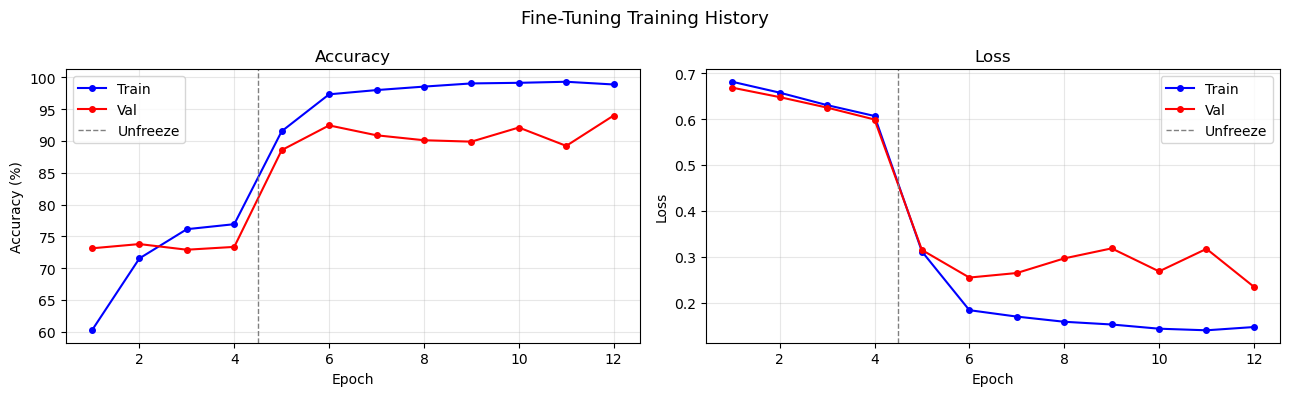

Final train acc: 98.9%  |  Final val acc: 94.0%  |  Gap: 4.9%
✅ Training looks healthy.


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
xs = range(1, len(history['tr_acc'])+1)

ax1.plot(xs, [a*100 for a in history['tr_acc']], 'b-o', ms=4, label='Train')
ax1.plot(xs, [a*100 for a in history['vl_acc']], 'r-o', ms=4, label='Val')
ax1.axvline(FREEZE_EPOCHS+0.5, color='gray', ls='--', lw=1, label='Unfreeze')
ax1.set(xlabel='Epoch', ylabel='Accuracy (%)', title='Accuracy'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(xs, history['tr_loss'], 'b-o', ms=4, label='Train')
ax2.plot(xs, history['vl_loss'], 'r-o', ms=4, label='Val')
ax2.axvline(FREEZE_EPOCHS+0.5, color='gray', ls='--', lw=1, label='Unfreeze')
ax2.set(xlabel='Epoch', ylabel='Loss', title='Loss'); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Fine-Tuning Training History', fontsize=13)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Diagnose overfitting
tr_final = history['tr_acc'][-1]*100
vl_final = history['vl_acc'][-1]*100
gap      = tr_final - vl_final
print(f'Final train acc: {tr_final:.1f}%  |  Final val acc: {vl_final:.1f}%  |  Gap: {gap:.1f}%')
if gap > 15:
    print('⚠️  Large train/val gap → overfitting. Try: raise DROPOUT, raise EPOCHS, or raise FRAMES_PER_VIDEO.')
elif vl_final < 75:
    print('⚠️  Val acc still low. Try: raise EPOCHS to 15, or raise FRAMES_PER_VIDEO to 40.')
else:
    print('✅ Training looks healthy.')

## Cell 11 — Evaluate on Held-Out Test Set

Loads the **best checkpoint** and reports frame-level accuracy + confusion matrix
on the 15% of data the model never saw.

=== Frame-Level Test Results (threshold=0.45) ===
              precision    recall  f1-score   support

    Real (0)      0.801     1.000     0.889       450
    Fake (1)      1.000     0.751     0.858       450

    accuracy                          0.876       900
   macro avg      0.900     0.876     0.874       900
weighted avg      0.900     0.876     0.874       900



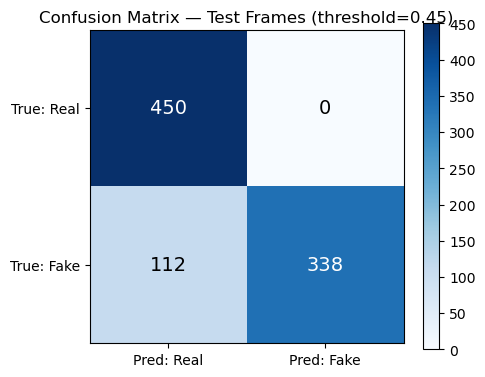

In [13]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs   = imgs.to(device)
        probs  = torch.sigmoid(model(imgs)).cpu().numpy()
        preds  = (probs > THRESHOLD).astype(int)
        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.int().tolist())

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)

print(f'=== Frame-Level Test Results (threshold={THRESHOLD}) ===')
print(classification_report(all_labels, all_preds,
                             target_names=['Real (0)', 'Fake (1)'], digits=3))

# Confusion matrix plot
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Pred: Real','Pred: Fake'])
ax.set_yticklabels(['True: Real','True: Fake'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=14,
                color='white' if cm[i,j] > cm.max()/2 else 'black')
ax.set_title(f'Confusion Matrix — Test Frames (threshold={THRESHOLD})')
plt.colorbar(im); plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 12 — Run Inference on Held-Out Test Videos Only (No Data Leakage)

**Fixed:** this used to loop over all 200 videos in `FAKE_FOLDER`/`REAL_FOLDER` — but
most of those videos were already used (via their extracted frames) to train the
model in Cell 9, so scoring them again told you how well the model memorised the
training set, not how well it generalises.

It now only scores the videos whose *entire video* — every frame — was held out of
`train_data` and `val_data` in Cell 6 (`fake_test_keys` / `real_test_keys`, ~15% of
videos each). Frames are scored individually and aggregated with a weighted mean
(MTCNN-detected face frames weighted 3× over fallback crops).


In [14]:
# Reload best model weights
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

def analyze_video(video_path, frame_stride=None, max_frames=MAX_FRAMES):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return {'verdict':'ERROR','confidence':None,'faces_found':0,'fallback_used':0,'frames_checked':0}

    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    if frame_stride is None:
        frame_stride = 5 if (w <= 256 or h <= 256) else 8

    tensors, face_flags = [], []
    fidx = face_n = fallback_n = 0

    while len(tensors) < max_frames:
        ret, bgr = cap.read()
        if not ret: break
        if fidx % frame_stride == 0:
            rgb          = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
            pil_face, ok = get_face_pil(rgb)
            pil_face     = pil_face.resize((IMG_SIZE, IMG_SIZE))
            tensors.append(eval_tf(pil_face))
            face_flags.append(ok)
            face_n    += int(ok)
            fallback_n += int(not ok)
        fidx += 1
    cap.release()

    if not tensors:
        return {'verdict':'UNKNOWN','confidence':None,'faces_found':0,'fallback_used':0,'frames_checked':fidx}

    all_probs = []
    with torch.no_grad():
        for i in range(0, len(tensors), 16):
            batch  = torch.stack(tensors[i:i+16]).to(device)
            probs  = torch.sigmoid(model(batch)).cpu().numpy()
            all_probs.extend(probs.tolist())

    weights    = [3.0 if f else 1.0 for f in face_flags]
    mean_score = sum(p*w for p,w in zip(all_probs,weights)) / sum(weights)
    verdict    = 'DEEPFAKE' if mean_score > THRESHOLD else 'REAL'

    return {'verdict':verdict,'confidence':float(mean_score),
            'faces_found':face_n,'fallback_used':fallback_n,'frames_checked':fidx}

# ── Collect ONLY the held-out test videos (fake_test_keys / real_test_keys come ──
# ── from Cell 6's per-video split) — this is what makes the accuracy below a  ────
# ── genuine measure of generalisation instead of recycled training data.     ────
video_files = []
for ext in VIDEO_EXTENSIONS:
    for p in sorted(Path(FAKE_FOLDER).glob(ext)):
        if p.stem in fake_test_keys:
            video_files.append((p, 'DEEPFAKE'))
    for p in sorted(Path(REAL_FOLDER).glob(ext)):
        if p.stem in real_test_keys:
            video_files.append((p, 'REAL'))

n_total_videos = len(fake_test_keys) + len(real_test_keys)
if len(video_files) != n_total_videos:
    print(f'⚠️  Expected {n_total_videos} held-out videos but matched {len(video_files)} files on disk — '
          f'check that FAKE_FOLDER/REAL_FOLDER still point at the same videos used in Cell 5.')

print(f'🎬 Running inference on {len(video_files)} HELD-OUT test videos never seen during training (threshold={THRESHOLD})...')

records, errors = [], []
for vf, true_label in tqdm(video_files, desc='Inference'):
    try:
        r = analyze_video(str(vf))
        verdict = r['verdict']
        correct = (verdict == true_label) if verdict not in ('UNKNOWN','ERROR') else None
        records.append({'file':vf.name,'true_label':true_label,'verdict':verdict,
                        'correct':correct,
                        'deepfake_prob': round(r['confidence'],4) if r['confidence'] else None,
                        'faces_found':r['faces_found'],'fallback_used':r['fallback_used'],
                        'frames_checked':r['frames_checked']})
    except Exception as e:
        errors.append((vf.name, str(e)))
        records.append({'file':vf.name,'true_label':true_label,'verdict':'ERROR',
                        'correct':None,'deepfake_prob':None,
                        'faces_found':0,'fallback_used':0,'frames_checked':0})
print(f'\n✅ Done. {len(errors)} errors.')


🎬 Running inference on 30 HELD-OUT test videos never seen during training (threshold=0.45)...


Inference:   0%|          | 0/30 [00:00<?, ?it/s]


✅ Done. 0 errors.


## Cell 13 — Results Table & Accuracy

In [15]:
df = pd.DataFrame(records)

def cv(val):
    if val=='DEEPFAKE': return 'background-color:#ffcccc'
    if val=='REAL':     return 'background-color:#ccffcc'
    return 'background-color:#ffffcc'
def cc(val):
    if val is True:  return 'background-color:#ccffcc;font-weight:bold'
    if val is False: return 'background-color:#ffcccc;font-weight:bold'
    return ''

display(df.style.applymap(cv, subset=['verdict','true_label']).applymap(cc, subset=['correct']))

valid = df[df['correct'].notna()]
if len(valid):
    acc = valid['correct'].mean()*100
    print(f'\n=== Final Results (fine-tuned, threshold={THRESHOLD}) ===')
    print(f'Overall accuracy : {acc:.1f}%  ({int(valid["correct"].sum())} / {len(valid)} correct)')
    print(f'\nPer class:')
    print(valid.groupby('true_label')['correct'].mean().apply(lambda x: f'{x*100:.1f}%').to_string())
    fn = len(df[(df['true_label']=='DEEPFAKE')&(df['verdict']=='REAL')])
    fp = len(df[(df['true_label']=='REAL')&(df['verdict']=='DEEPFAKE')])
    print(f'\nFalse Negatives (fakes missed)    : {fn}')
    print(f'False Positives (real mis-flagged) : {fp}')
    print(f'\nIf FN is still high → lower THRESHOLD (e.g. 0.35)')
    print(f'If FP is high       → raise THRESHOLD (e.g. 0.50)')

df.to_csv(OUTPUT_CSV, index=False)
print(f'\n✅ Saved to {OUTPUT_CSV}')

,file,true_label,verdict,correct,deepfake_prob,faces_found,fallback_used,frames_checked
0,04_02.mp4,DEEPFAKE,DEEPFAKE,True,0.913500,90,0,450
1,05_12.mp4,DEEPFAKE,DEEPFAKE,True,0.924600,90,0,450
2,11_17.mp4,DEEPFAKE,DEEPFAKE,True,0.875800,90,0,450
3,13_16.mp4,DEEPFAKE,DEEPFAKE,True,0.727800,90,0,450
4,14_14.mp4,DEEPFAKE,DEEPFAKE,True,0.610900,90,0,450
5,17_12.mp4,DEEPFAKE,DEEPFAKE,True,0.877600,90,0,450
6,28_22.mp4,DEEPFAKE,DEEPFAKE,True,0.879900,90,0,450
7,31_05.mp4,DEEPFAKE,DEEPFAKE,True,0.813000,90,0,450
8,35_35.mp4,DEEPFAKE,REAL,False,0.417800,90,0,450
9,54_56.mp4,DEEPFAKE,DEEPFAKE,True,0.881100,90,0,450



=== Final Results (fine-tuned, threshold=0.45) ===
Overall accuracy : 93.3%  (28 / 30 correct)

Per class:
true_label
DEEPFAKE     86.7%
REAL        100.0%

False Negatives (fakes missed)    : 2
False Positives (real mis-flagged) : 0

If FN is still high → lower THRESHOLD (e.g. 0.35)
If FP is high       → raise THRESHOLD (e.g. 0.50)

✅ Saved to deepfake_results_finetuned.csv


## Cell 14 — Per-Video Score Chart

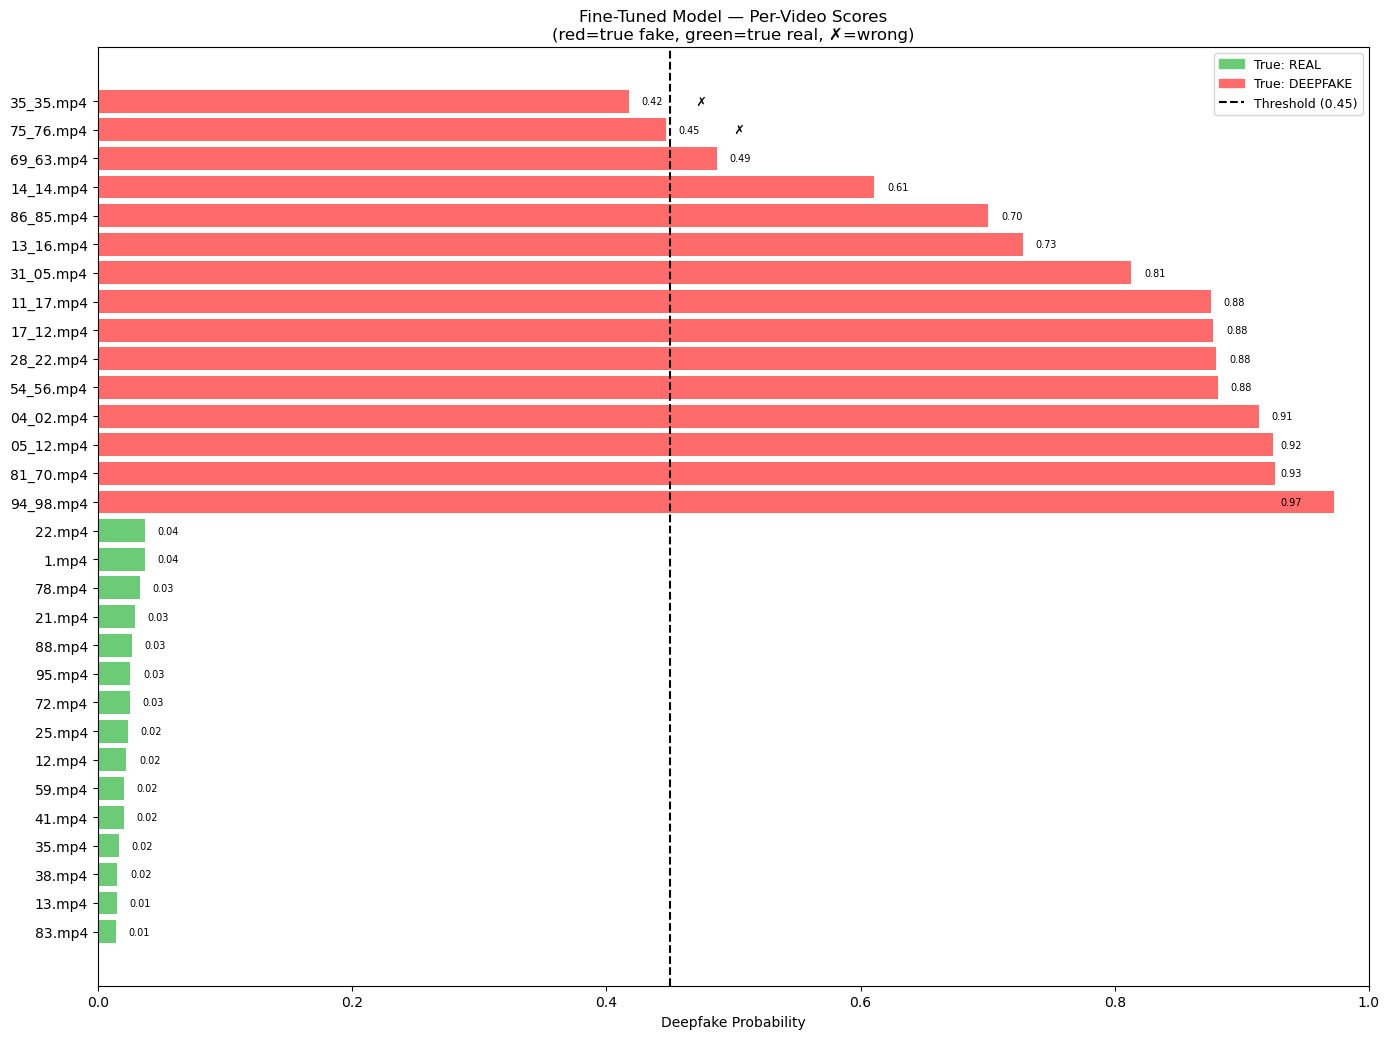

✅ Chart saved.


In [16]:
plot_df = df[df['deepfake_prob'].notna()].copy()
real_df = plot_df[plot_df['true_label']=='REAL'].sort_values('deepfake_prob')
fake_df = plot_df[plot_df['true_label']=='DEEPFAKE'].sort_values('deepfake_prob', ascending=False)
plot_df = pd.concat([real_df, fake_df])

colors = ['#ff6b6b' if l=='DEEPFAKE' else '#6bcb77' for l in plot_df['true_label']]
fig, ax = plt.subplots(figsize=(14, max(8, len(plot_df)*0.35)))
ax.barh(plot_df['file'], plot_df['deepfake_prob'], color=colors)
ax.axvline(THRESHOLD, color='black', ls='--', lw=1.5, label=f'Threshold ({THRESHOLD})')
ax.set(xlabel='Deepfake Probability', xlim=(0,1),
       title='Fine-Tuned Model — Per-Video Scores\n(red=true fake, green=true real, ✗=wrong)')

for bar, (_, row) in zip(ax.patches, plot_df.iterrows()):
    x = row['deepfake_prob']
    ax.text(min(x+0.01,0.93), bar.get_y()+bar.get_height()/2, f'{x:.2f}', va='center', fontsize=7)
    if row['correct'] is False:
        ax.text(min(x+0.05,0.97), bar.get_y()+bar.get_height()/2, ' ✗', va='center', fontsize=9, fontweight='bold')

ax.legend(handles=[mpatches.Patch(color='#6bcb77',label='True: REAL'),
                   mpatches.Patch(color='#ff6b6b',label='True: DEEPFAKE'),
                   ax.lines[0]], fontsize=9)
plt.tight_layout()
plt.savefig('finetuned_scores_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved.')

## Cell 15 — Hyperparameter Tuning Guide

### If accuracy is still below 85% after training

| Symptom | Cause | Fix |
|---|---|---|
| Train acc high, val acc low (>15% gap) | Overfitting | Raise `DROPOUT` to 0.6, raise `FRAMES_PER_VIDEO` to 40 |
| Both train & val acc low (~60%) | Underfitting | Raise `EPOCHS` to 15, lower `LR_HEAD` to 1e-4 |
| Many fakes still missed (high FN) | Threshold too high | Lower `THRESHOLD` to 0.35 |
| Real videos being flagged as fake | Threshold too low | Raise `THRESHOLD` to 0.50 |
| Val acc plateaus early | LR too high | Lower `LR_FULL` to 2e-5 |

### Quick wins to try first (in order)
1. Lower `THRESHOLD` to `0.35` in Cell 3 → re-run Cells 12–13 only (no retraining needed)
2. Raise `FRAMES_PER_VIDEO` to `40`, delete `extracted_frames/`, re-run Cells 5–13
3. Raise `EPOCHS` to `15`, re-run Cells 9–13

### If training on CPU is too slow
Upload to [Google Colab](https://colab.research.google.com) — free T4 GPU cuts training from ~30 min to ~3 min.  
In Colab: `Runtime → Change runtime type → T4 GPU`